# Business Analytics Report — Private Health Insurance in Australia
### Assessment 3 | Autumn 2026

**Student:** Paula Moreno
**Topic:** Long-term trends in Private Hospital Insurance (PHI) uptake and the sustainability of the PHI market
**Data sources:** APRA Quarterly Private Health Insurance Statistics; ABS Quarterly Estimated Resident Population by Age

This notebook investigates the long-term trends in Private Hospital Insurance (PHI)
membership in Australia and assesses the sustainability of the PHI market.
The analysis is structured across three sections:

1. **Section 1** — Data Exploration & Quality Assessment
2. **Section 2** — Descriptive & Exploratory Analysis of PHI Trends
3. **Section 3** — Discussion, Interpretation & Sustainability Outlook

The investigation focuses on whether PHI membership and coverage rates declined in
the lead-up to the COVID-19 pandemic, how trends differed across age groups, and
how the market behaved during and after the pandemic.

---
## Section 1 — Data Exploration and Quality Assessment

Before conducting any analysis, it is essential to understand the structure of the
datasets, evaluate their quality, and identify any limitations that may affect how
results should be interpreted.

This section covers:
- Loading and previewing both datasets
- Inspecting column names, data types, and row counts
- Checking for missing values, duplicates, and outliers
- Cleaning the data and creating the key variable for analysis: **PHI Coverage Rate**

In [2]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings — wider tables, more rows visible
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Consistent chart style
sns.set_theme(style="white", rc={"figure.figsize": (12, 6)})
sns.set_context("notebook", font_scale=1.15, rc={"lines.linewidth": 2.5})

# Custom colour palette — colourblind-friendly, suitable for age-group comparisons
AGE_PALETTE = sns.color_palette("viridis", n_colors=5)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Quarterly Private Health Insurance Membership Trends December 2025 (1).xlsx to Quarterly Private Health Insurance Membership Trends December 2025 (1) (1).xlsx
Saving Austalian quarterly population by age.xlsx to Austalian quarterly population by age (1).xlsx


In [4]:
# Load both files and check sheet names
apra_membership = pd.ExcelFile('Quarterly Private Health Insurance Membership Trends December 2025 (1).xlsx')
abs_population = pd.ExcelFile('Austalian quarterly population by age.xlsx')

print("=== APRA MEMBERSHIP SHEETS ===")
print(apra_membership.sheet_names)

print("\n=== ABS POPULATION SHEETS ===")
print(abs_population.sheet_names)

=== APRA MEMBERSHIP SHEETS ===
['Cover', 'Selection', 'Notes ', 'Contents', 'HT % coverage', 'HT & GT pol.inspers', 'HT Membership', 'HT by Age ', 'HT by policy type', 'H-ST by Age', 'CDMP by Age', 'GT by Age', 'GT % coverage', 'Average age of HT member', 'Notes on Statistics', 'RelatedPublications', 'MembershipData', 'MembershipByAgeData']

=== ABS POPULATION SHEETS ===
['Table Transposed']


### 1.1 Loading the APRA PHI Membership Dataset

In [5]:
# File paths
APRA_FILE = 'Quarterly Private Health Insurance Membership Trends December 2025 (1).xlsx'
ABS_FILE  = 'Austalian quarterly population by age.xlsx'

# Load the Total Male + Female block from the 'HT by Age' sheet
# - header=34: row 34 contains the column names (Quarter, 0-4, ..., 95+, Total)
# - usecols='A:V': only the first block (Total Persons), 22 columns wide
phi_raw = pd.read_excel(
    APRA_FILE,
    sheet_name='HT by Age ',
    header=34,
    usecols='A:V'
)

# Preview
print("Shape:", phi_raw.shape)
phi_raw.head()

Shape: (114, 22)


,Quarter,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90-94,95+,Total
0,1997-09-30,317962,354654,390670,365913,233893,264023,341612,414953,444277,476474,448047,347113,278316,257697,216843,147320,98754,52277,17755,4621,5473174
1,1997-12-31,336069,373485,424833,399366,254690,279589,361636,442999,476287,512686,490709,377270,302833,276746,232840,158636,104364,55689,18983,4914,5884624
2,1998-03-31,329650,367058,418911,393136,245798,272001,353251,436533,469711,506663,490781,376328,302001,273368,234944,160087,103818,56068,19225,4961,5814293
3,1998-06-30,325620,361475,412679,382504,230686,264435,346175,429904,463505,499820,490001,374690,299592,268573,234476,159770,103389,56353,19364,4960,5727971
4,1998-09-30,321866,356640,408156,386511,237469,257654,340621,424118,458849,494810,490457,376521,300488,265978,234684,160343,102652,56514,19477,4932,5698740


**Expected result:** A clean table with 22 columns — `Quarter` plus 20 age groups plus
`Total` — and approximately 114 quarterly observations.


### 1.2 Loading the ABS Population Dataset

In [6]:
# Quick first look at the population file
pop_raw = pd.read_excel(ABS_FILE, sheet_name='Table Transposed')

# Preview
print("Shape:", pop_raw.shape)
print("\nFirst 5 rows:")
pop_raw.head()

Shape: (177, 20)

First 5 rows:


,Quarter,All ages,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85 and over
0,1981-09-30,14988677,1145785,1261204,1325733,1295175,1310522,1236108,1227817,1009849,842128,738509,772591,741833,618516,537294,405070,262872,154961,102710
1,1981-12-31,15054117,1145803,1253055,1335431,1292713,1317572,1242635,1228711,1031198,850400,741857,770692,743536,624603,539386,409600,265957,156829,104139
2,1982-03-31,15121698,1150448,1244057,1344996,1292181,1326092,1248014,1228612,1052185,858231,745006,768477,744918,630313,541122,414059,269132,158445,105410
3,1982-06-30,15184247,1155274,1235285,1354427,1288994,1333401,1253635,1228574,1073243,865803,748322,766107,746262,636152,542837,418048,271841,159851,106191
4,1982-09-30,15239278,1159647,1229712,1359234,1286988,1338716,1259345,1232575,1090958,872230,753198,762619,748044,642548,542493,421010,274061,160420,105480


We need to inspect:
- How the time variable is structured (column or row labels)
- What age bands are used and whether they match APRA's 5-year bands
- Whether there are any header rows, totals, or metadata to clean

# 1.3 Cleaning and Reshaping the Data

Before the PHI coverage rate can be calculated, both datasets must be made structurally
compatible. Three preparations are required:

1. **Aggregating APRA's elderly age bands.** APRA reports persons aged 85+ in three
   separate bands (`85-89`, `90-94`, `95+`), while the ABS reports a single combined
   `85 and over` group. The APRA bands are summed into a single `85+` group to match.

2. **Standardising age-group column names** across both datasets.

3. **Reshaping both datasets from wide to long format.** A long-format table — with one
   row per (quarter, age-group) combination — is the natural structure for merging the
   two sources and for the subsequent analysis and visualisation steps.

These transformations preserve all of the underlying information; they simply restructure
it for clean joining and consistent downstream use.


In [7]:
# === STEP A: Aggregate APRA's elderly bands into a single 85+ group ===

phi_clean = phi_raw.copy()
phi_clean['85+'] = phi_clean['85-89'] + phi_clean['90-94'] + phi_clean['95+']
phi_clean = phi_clean.drop(columns=['85-89', '90-94', '95+'])

# Quick check
print("APRA shape after aggregation:", phi_clean.shape)
phi_clean.head()

APRA shape after aggregation: (114, 20)


,Quarter,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,Total,85+
0,1997-09-30,317962,354654,390670,365913,233893,264023,341612,414953,444277,476474,448047,347113,278316,257697,216843,147320,98754,5473174,74653
1,1997-12-31,336069,373485,424833,399366,254690,279589,361636,442999,476287,512686,490709,377270,302833,276746,232840,158636,104364,5884624,79586
2,1998-03-31,329650,367058,418911,393136,245798,272001,353251,436533,469711,506663,490781,376328,302001,273368,234944,160087,103818,5814293,80254
3,1998-06-30,325620,361475,412679,382504,230686,264435,346175,429904,463505,499820,490001,374690,299592,268573,234476,159770,103389,5727971,80677
4,1998-09-30,321866,356640,408156,386511,237469,257654,340621,424118,458849,494810,490457,376521,300488,265978,234684,160343,102652,5698740,80923


In [8]:
# === STEP B: Standardise ABS column names ===

pop_clean = pop_raw.copy()
pop_clean = pop_clean.rename(columns={'85 and over': '85+'})

# Drop the "All ages" column — we will reconstruct totals later if needed
pop_clean = pop_clean.drop(columns=['All ages'])

print("ABS shape after renaming:", pop_clean.shape)
pop_clean.head()

ABS shape after renaming: (177, 19)


,Quarter,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85+
0,1981-09-30,1145785,1261204,1325733,1295175,1310522,1236108,1227817,1009849,842128,738509,772591,741833,618516,537294,405070,262872,154961,102710
1,1981-12-31,1145803,1253055,1335431,1292713,1317572,1242635,1228711,1031198,850400,741857,770692,743536,624603,539386,409600,265957,156829,104139
2,1982-03-31,1150448,1244057,1344996,1292181,1326092,1248014,1228612,1052185,858231,745006,768477,744918,630313,541122,414059,269132,158445,105410
3,1982-06-30,1155274,1235285,1354427,1288994,1333401,1253635,1228574,1073243,865803,748322,766107,746262,636152,542837,418048,271841,159851,106191
4,1982-09-30,1159647,1229712,1359234,1286988,1338716,1259345,1232575,1090958,872230,753198,762619,748044,642548,542493,421010,274061,160420,105480


In [9]:
# === STEP C: Reshape both datasets from wide to long ===

# Define the final ordered list of age groups (used in both datasets)
AGE_GROUPS = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
              '40-44','45-49','50-54','55-59','60-64','65-69','70-74',
              '75-79','80-84','85+']

# PHI: wide -> long
phi_long = phi_clean.melt(
    id_vars='Quarter',
    value_vars=AGE_GROUPS,
    var_name='age_group',
    value_name='phi_members'
)

# Population: wide -> long
pop_long = pop_clean.melt(
    id_vars='Quarter',
    value_vars=AGE_GROUPS,
    var_name='age_group',
    value_name='population'
)

print("PHI long shape:", phi_long.shape)
print("Population long shape:", pop_long.shape)
print("\nPHI long preview:")
print(phi_long.head())
print("\nPopulation long preview:")
print(pop_long.head())

PHI long shape: (2052, 3)
Population long shape: (3186, 3)

PHI long preview:
     Quarter age_group  phi_members
0 1997-09-30       0-4       317962
1 1997-12-31       0-4       336069
2 1998-03-31       0-4       329650
3 1998-06-30       0-4       325620
4 1998-09-30       0-4       321866

Population long preview:
     Quarter age_group  population
0 1981-09-30       0-4     1145785
1 1981-12-31       0-4     1145803
2 1982-03-31       0-4     1150448
3 1982-06-30       0-4     1155274
4 1982-09-30       0-4     1159647


### 1.4 Constructing the PHI Coverage Rate

With both datasets cleaned and reshaped, the next step is to merge them on the
common keys (`Quarter` and `age_group`) and compute the central variable of
this analysis: the **PHI coverage rate**, defined as

$$
\text{Coverage Rate} = \frac{\text{PHI members in age group}}{\text{Population in age group}} \times 100
$$

This converts raw membership counts into a rate that controls for population size,
allowing meaningful comparison across age groups and over time. An inner join is
used so that only quarters present in **both** datasets are retained — this restricts
the analysis to the overlapping window of September 1997 to September 2025.

In [10]:
# === STEP D: Merge PHI and Population data ===

phi = phi_long.merge(
    pop_long,
    on=['Quarter', 'age_group'],
    how='inner'
)

# === STEP E: Calculate the PHI coverage rate (%) ===
phi['coverage_rate'] = (phi['phi_members'] / phi['population']) * 100

# Keep age_group ordered for clean charts later
phi['age_group'] = pd.Categorical(phi['age_group'], categories=AGE_GROUPS, ordered=True)

# Sort for readability
phi = phi.sort_values(['Quarter', 'age_group']).reset_index(drop=True)

# Preview
print("Final merged dataset shape:", phi.shape)
print("Time coverage:", phi['Quarter'].min().date(), "→", phi['Quarter'].max().date())
print("\nPreview:")
phi.head(10)

Final merged dataset shape: (2034, 5)
Time coverage: 1997-09-30 → 2025-09-30

Preview:


,Quarter,age_group,phi_members,population,coverage_rate
0,1997-09-30,0-4,317962,1292010,24.609871
1,1997-09-30,5-9,354654,1314746,26.975096
2,1997-09-30,10-14,390670,1305316,29.929151
3,1997-09-30,15-19,365913,1272745,28.749907
4,1997-09-30,20-24,233893,1342584,17.421107
5,1997-09-30,25-29,264023,1446757,18.249298
6,1997-09-30,30-34,341612,1416099,24.123455
7,1997-09-30,35-39,414953,1477936,28.076520
8,1997-09-30,40-44,444277,1376329,32.279855
9,1997-09-30,45-49,476474,1290924,36.909531


In [11]:
# Sanity check: do our coverage rates look reasonable?
print("Coverage rate summary (%):")
print(phi['coverage_rate'].describe().round(2))

print("\nAverage coverage rate by age group (across all quarters):")
print(phi.groupby('age_group', observed=True)['coverage_rate']
      .mean().round(2).to_string())

Coverage rate summary (%):
count    2034.00
mean       44.17
std         8.97
min        17.36
25%        38.07
50%        45.42
75%        50.81
max        60.68
Name: coverage_rate, dtype: float64

Average coverage rate by age group (across all quarters):
age_group
0-4      37.27
5-9      41.85
10-14    43.80
15-19    43.53
20-24    30.63
25-29    26.74
30-34    39.70
35-39    44.99
40-44    47.51
45-49    50.04
50-54    52.38
55-59    53.87
60-64    53.38
65-69    51.32
70-74    49.14
75-79    46.42
80-84    43.44
85+      39.10


---
## Section 2 — Descriptive and Exploratory Analysis

This section investigates the long-term trends in Private Hospital Insurance (PHI)
uptake in Australia using the cleaned dataset constructed in Section 1. The analysis
proceeds in four stages, each addressing one of the assessment's key questions:

| Subsection | Question Addressed |
|---|---|
| 2.1 | Has total PHI membership grown, declined, or stayed flat over time? |
| 2.2 | How has the PHI coverage rate evolved once population growth is accounted for? |
| 2.3 | Did younger people drop out at a different rate from middle-aged and older people? |
| 2.4 | How did the COVID-19 pandemic affect these trends? |

Each subsection presents a focused visualisation followed by interpretation. Section 3
then synthesises these findings into a broader discussion of market sustainability.

### 2.1 Long-Term Trend in Total PHI Membership

The first question is straightforward: is the *total number* of Australians holding
private hospital insurance going up, going down, or staying flat?

This is the headline figure most often reported in the press. However, it is also
the **most misleading** indicator on its own, because Australia's population has been
growing the entire time. A rising membership count could simply reflect a larger
population, even if the *share* of people insured is falling. For this reason, the
trend in total membership is best read alongside the coverage-rate analysis in
Section 2.2.

To make the timing of key policy and economic events visible, the chart highlights:
- **September 1999** — introduction of the 30% PHI Rebate
- **July 2000** — introduction of Lifetime Health Cover loading
- **March 2020** — onset of the COVID-19 pandemic in Australia

In [12]:
# Aggregate total PHI members across all age groups, per quarter
total_members = (
    phi.groupby('Quarter', as_index=False)['phi_members']
       .sum()
       .rename(columns={'phi_members': 'total_members'})
)

# Convert to millions for cleaner labels
total_members['members_millions'] = total_members['total_members'] / 1_000_000

print("Preview:")
print(total_members.head())
print("\nLatest 3 quarters:")
print(total_members.tail(3))

Preview:
     Quarter  total_members  members_millions
0 1997-09-30        5473174          5.473174
1 1997-12-31        5884624          5.884624
2 1998-03-31        5814293          5.814293
3 1998-06-30        5727971          5.727971
4 1998-09-30        5698740          5.698740

Latest 3 quarters:
       Quarter  total_members  members_millions
110 2025-03-31       12482109         12.482109
111 2025-06-30       12531009         12.531009
112 2025-09-30       12633931         12.633931


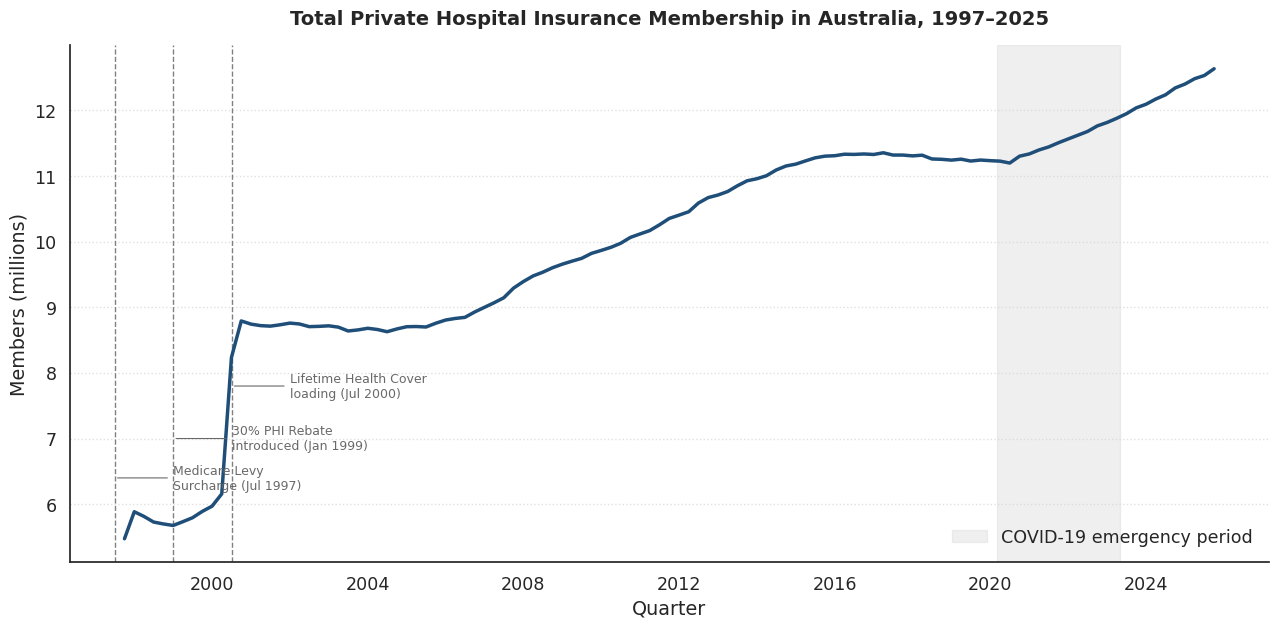

In [13]:
# === Chart 2.1: Total PHI membership over time ===
fig, ax = plt.subplots(figsize=(13, 6.5))

# Main line
ax.plot(total_members['Quarter'], total_members['members_millions'],
        color='#1f4e79', linewidth=2.5, zorder=3)

# Shade the COVID period (Mar 2020 onwards)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-05-05'),
           color='lightgrey', alpha=0.35, label='COVID-19 emergency period')

# Annotate key policy events with staggered labels to avoid overlap
events = [
    ('1997-07-01', 'Medicare Levy\nSurcharge (Jul 1997)', 6.4),
    ('1999-01-01', '30% PHI Rebate\nintroduced (Jan 1999)', 7.0),
    ('2000-07-01', 'Lifetime Health Cover\nloading (Jul 2000)', 7.8),
]
for date, label, y_pos in events:
    d = pd.Timestamp(date)
    ax.axvline(d, color='grey', linestyle='--', linewidth=1, zorder=2)
    ax.annotate(
        label,
        xy=(d, y_pos),
        xytext=(d + pd.Timedelta(days=550), y_pos),
        fontsize=9, color='dimgrey', va='center',
        arrowprops=dict(arrowstyle='-', color='dimgrey', lw=0.8)
    )

# Labels and formatting
ax.set_title('Total Private Hospital Insurance Membership in Australia, 1997–2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quarter')
ax.set_ylabel('Members (millions)')
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=False)

# Clean spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation.** The chart reveals four distinct phases in Australian PHI membership.
Between 1997 and mid-1999, total membership was flat at around 5.5–5.7 million people.
A sharp acceleration then occurred between September 1999 and mid-2000, following the
introduction of the 30% PHI Rebate and the Lifetime Health Cover (LHC) loading — two
policy interventions specifically designed to lift uptake. Membership rose from around
6 million to almost 8.8 million within roughly a year, a 45% increase that ranks among
the most pronounced policy-driven shifts in the history of Australian health insurance.

From 2001 to 2019, membership grew steadily but more slowly, reaching around 11.3 million
by the eve of the COVID-19 pandemic. During the first phase of the pandemic (2020 to
mid-2021), the growth temporarily plateaued. Contrary to pre-pandemic concerns about a
collapsing market, however, membership then **accelerated sharply** from 2022 onwards,
reaching 12.6 million by the end of the series.

Two important caveats apply when reading this chart. First, total membership figures do
not control for Australia's growing population; an increase in members could partly or
entirely reflect demographic growth rather than genuine increases in PHI demand. Second,
the aggregate picture conceals important variation across age groups — the question of
whether *younger* Australians have been leaving the market cannot be addressed from this
chart alone. Both issues are taken up in the subsequent sections.

### 2.2 Long-Term Trend in PHI Coverage Rate

While Section 2.1 showed that the raw count of PHI members has grown over time, this
figure is influenced by population growth and therefore cannot indicate whether the
*share* of Australians choosing to be privately insured is rising or falling. The
**PHI coverage rate** — the proportion of the resident population holding hospital
treatment cover — corrects for this and is the more economically meaningful indicator
of market health.

For the population-wide coverage rate, the total number of insured persons across all
age groups is divided by the total Australian population in each quarter. This figure
is then tracked from September 1997 to September 2025 to identify any sustained
decline in the lead-up to the COVID-19 pandemic, and to determine whether the trend
shifted during and after the pandemic.

In [14]:
# Aggregate PHI members and population across all age groups, per quarter
national = (
    phi.groupby('Quarter', as_index=False)[['phi_members', 'population']]
       .sum()
)

# Calculate the national coverage rate
national['coverage_rate'] = (national['phi_members'] / national['population']) * 100

print("Preview:")
print(national.head())
print("\nLatest 3 quarters:")
print(national.tail(3))
print("\nKey snapshots:")
for label, date in [('Pre-rebate (Jun 1999)',  '1999-06-30'),
                    ('Post-LHC peak (Dec 2000)','2000-12-31'),
                    ('Pre-COVID (Dec 2019)',   '2019-12-31'),
                    ('Latest (Sep 2025)',      '2025-09-30')]:
    val = national.loc[national['Quarter'] == date, 'coverage_rate'].values
    if len(val) > 0:
        print(f"  {label}: {val[0]:.2f}%")

Preview:
     Quarter  phi_members  population  coverage_rate
0 1997-09-30      5473174    18468718      29.634834
1 1997-12-31      5884624    18510004      31.791587
2 1998-03-31      5814293    18572416      31.306067
3 1998-06-30      5727971    18607584      30.782991
4 1998-09-30      5698740    18658381      30.542521

Latest 3 quarters:
       Quarter  phi_members  population  coverage_rate
110 2025-03-31     12482109    27531443      45.337649
111 2025-06-30     12531009    27613654      45.379757
112 2025-09-30     12633931    27724744      45.569153

Key snapshots:
  Pre-rebate (Jun 1999): 30.79%
  Post-LHC peak (Dec 2000): 45.68%
  Pre-COVID (Dec 2019): 44.02%
  Latest (Sep 2025): 45.57%


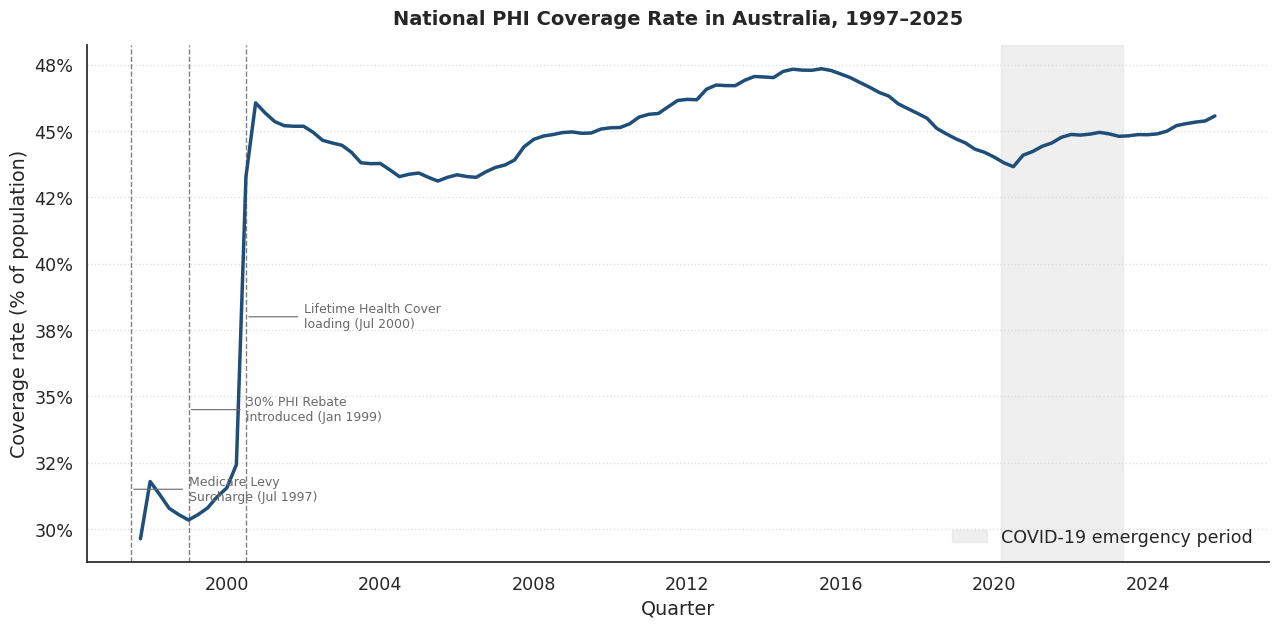

In [15]:
# === Chart 2.2: National PHI coverage rate over time ===
fig, ax = plt.subplots(figsize=(13, 6.5))

# Main line
ax.plot(national['Quarter'], national['coverage_rate'],
        color='#1f4e79', linewidth=2.5, zorder=3)

# Shade the COVID period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-05-05'),
           color='lightgrey', alpha=0.35, label='COVID-19 emergency period')

# Annotate key events
events = [
    ('1997-07-01', 'Medicare Levy\nSurcharge (Jul 1997)', 31.5),
    ('1999-01-01', '30% PHI Rebate\nintroduced (Jan 1999)', 34.5),
    ('2000-07-01', 'Lifetime Health Cover\nloading (Jul 2000)', 38.0),
]
for date, label, y_pos in events:
    d = pd.Timestamp(date)
    ax.axvline(d, color='grey', linestyle='--', linewidth=1, zorder=2)
    ax.annotate(
        label,
        xy=(d, y_pos),
        xytext=(d + pd.Timedelta(days=550), y_pos),
        fontsize=9, color='dimgrey', va='center',
        arrowprops=dict(arrowstyle='-', color='dimgrey', lw=0.8)
    )

# Labels and formatting
ax.set_title('National PHI Coverage Rate in Australia, 1997–2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quarter')
ax.set_ylabel('Coverage rate (% of population)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=False)

# Clean spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation.** Once population growth is accounted for, the picture of the PHI
market changes substantially. The coverage rate rose dramatically from approximately
30% in mid-1999 to a peak of around 46% by late 2000, driven by the 30% PHI Rebate
(Sep 1999) and the Lifetime Health Cover loading (Jul 2000). For the next two decades,
the coverage rate fluctuated in a relatively narrow band between 43% and 47%, but the
underlying pattern is not flat.

Three sub-periods are worth noting:

- **Post-policy peak (2000–2007).** Coverage initially drifted downward from its 2000
  peak, suggesting that some of the gains from the 1999–2000 reforms were not sustained
  in the medium term.
- **Recovery (2007–2015).** Coverage climbed back to approximately 47%, the highest
  level since the introduction of the policies.
- **Pre-COVID decline (2015–2019).** From around 2015, coverage began to **fall
  steadily**, dropping from approximately 47% to 44% over four years. This is the
  trend that prompted observers — notably the Grattan Institute (Duckett & Moran, 2021)
  — to warn of a possible "death spiral" in the PHI market.

The decline continued into the early COVID period (2020–2021), with coverage reaching
its lowest point in roughly two decades at around 43.5%. From 2022 onward, however,
the coverage rate **recovered**, rising back to approximately 46% by 2025 — close to,
though still below, the 2015 peak.

These findings provide a more nuanced answer to the first assessment question. Total
membership has grown almost continuously, but the *share* of Australians privately
insured did decline in the immediate lead-up to the pandemic, consistent with concerns
about young, healthy consumers exiting the market. However, the post-2022 reversal
suggests that the trend was neither linear nor irreversible. The aggregate picture
still conceals important variation across age groups, which is examined in Section 2.3.

### 2.3 Trends in PHI Coverage Rate by Age Group

The national coverage rate examined in Section 2.2 conceals significant variation
across age groups. The "death spiral" hypothesis depends specifically on the behaviour
of **younger, healthier adults**: if they leave the market disproportionately, the
remaining pool of insured persons becomes older and sicker on average, pushing
premiums up and triggering further exits.

To test this mechanism, the 18 five-year age bands have been collapsed into four
economically meaningful groups:

| Group | Ages | Rationale |
|---|---|---|
| Young adults | 20–34 | Group most likely to exit; central to the death-spiral hypothesis |
| Middle-aged | 35–54 | Family-formation and peak-earning years |
| Older pre-retirement | 55–69 | Approaching higher health needs; typically highest PHI uptake |
| Elderly | 70+ | Increasing reliance on Medicare and public services |

Children and adolescents (0–19) are excluded from this comparison because their PHI
status is determined by parental choice and therefore reveals little about voluntary
demand fo

In [16]:
# Map five-year age bands into four broader groups
def assign_age_band(ag):
    young   = ['20-24','25-29','30-34']
    middle  = ['35-39','40-44','45-49','50-54']
    older   = ['55-59','60-64','65-69']
    elderly = ['70-74','75-79','80-84','85+']
    if ag in young:   return 'Young adults (20–34)'
    if ag in middle:  return 'Middle-aged (35–54)'
    if ag in older:   return 'Older pre-retirement (55–69)'
    if ag in elderly: return 'Elderly (70+)'
    return None  # children excluded

phi['age_band'] = phi['age_group'].astype(str).apply(assign_age_band)

# Aggregate by quarter and age band
age_band_trend = (
    phi.dropna(subset=['age_band'])
       .groupby(['Quarter', 'age_band'], as_index=False, observed=True)
       .agg({'phi_members': 'sum', 'population': 'sum'})
)
age_band_trend['coverage_rate'] = (
    age_band_trend['phi_members'] / age_band_trend['population']
) * 100

# Preserve a sensible order for the legend
band_order = ['Young adults (20–34)',
              'Middle-aged (35–54)',
              'Older pre-retirement (55–69)',
              'Elderly (70+)']
age_band_trend['age_band'] = pd.Categorical(
    age_band_trend['age_band'], categories=band_order, ordered=True
)

# Show a quick snapshot
snapshot = (age_band_trend[age_band_trend['Quarter']
            .isin(pd.to_datetime(['2000-12-31','2015-06-30','2019-12-31','2025-09-30']))]
            .pivot(index='age_band', columns='Quarter', values='coverage_rate')
            .round(2))
print("Coverage rate (%) at key snapshots:\n")
print(snapshot)

Coverage rate (%) at key snapshots:

Quarter                       2000-12-31  2015-06-30  2019-12-31  2025-09-30
age_band                                                                    
Young adults (20–34)               33.50       37.06       30.52       32.32
Middle-aged (35–54)                55.29       51.28       48.18       49.84
Older pre-retirement (55–69)       51.80       56.92       52.67       51.91
Elderly (70+)                      37.23       49.78       51.72       53.99


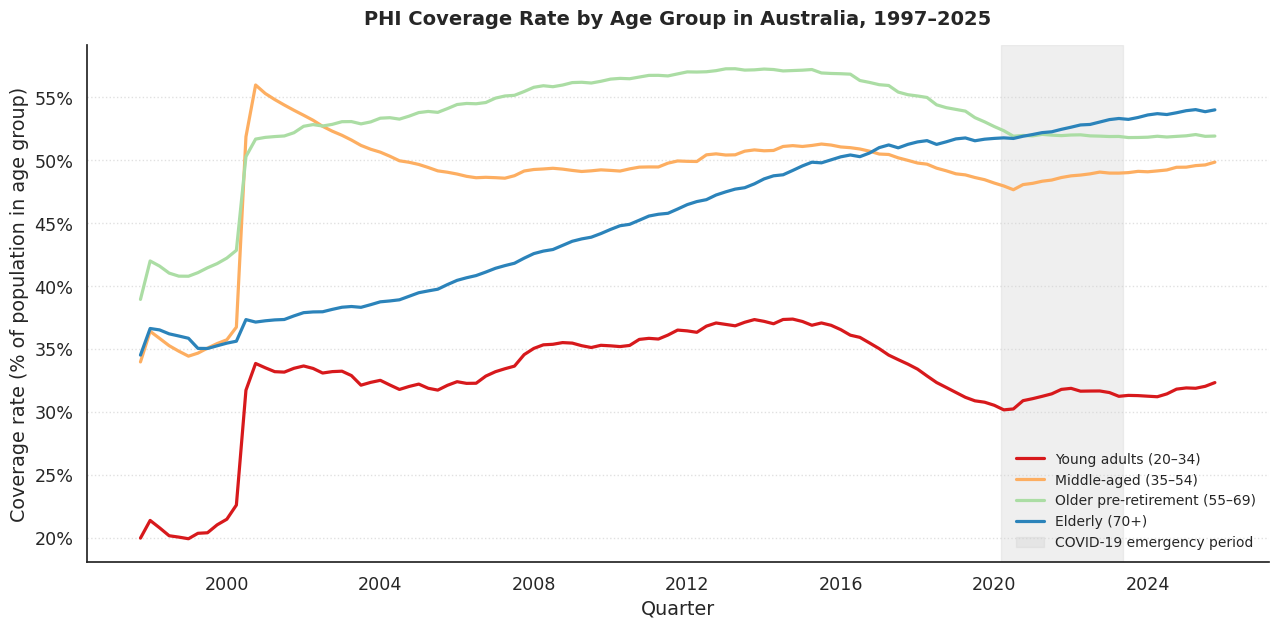

In [17]:
# === Chart 2.3: PHI coverage rate by age band over time ===
fig, ax = plt.subplots(figsize=(13, 6.5))

# Colour-blind friendly palette, ordered young → elderly
palette = ['#d7191c',  # young adults — red (drop-out risk group)
           '#fdae61',  # middle-aged — orange
           '#abdda4',  # older pre-retirement — green
           '#2b83ba']  # elderly — blue

for band, colour in zip(band_order, palette):
    sub = age_band_trend[age_band_trend['age_band'] == band]
    ax.plot(sub['Quarter'], sub['coverage_rate'],
            label=band, color=colour, linewidth=2.3)

# Shade COVID period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-05-05'),
           color='lightgrey', alpha=0.35, label='COVID-19 emergency period')

# Labels and formatting
ax.set_title('PHI Coverage Rate by Age Group in Australia, 1997–2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quarter')
ax.set_ylabel('Coverage rate (% of population in age group)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=False, fontsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation.** Disaggregating the national coverage rate by age group reveals
that the pre-COVID decline identified in Section 2.2 was **not uniform across the
population**. Instead, the four age groups followed sharply divergent paths.

- **Young adults (20–34)** experienced by far the steepest decline. Their coverage
  rate peaked at approximately 37% in mid-2015 and fell to roughly 30.5% by late 2019
  — a drop of about 6.6 percentage points in just over four years. This is the clearest
  empirical signature of the "death spiral" mechanism: the very age group most expected
  to exit a deteriorating market did so the fastest.
- **Middle-aged adults (35–54)** also lost coverage in the pre-COVID period, but more
  gradually, falling from around 51% in 2015 to 48% in 2019. Their decline appears to
  pre-date 2015 — coverage in this group has been drifting downward almost continuously
  since the early 2000s.
- **Older pre-retirement adults (55–69)** showed only a modest dip pre-COVID, falling
  from a peak of around 57% in 2015 to about 53% in 2019. This group has historically
  held the highest coverage rate of any age band.
- **The elderly (70+)** are the striking exception: their coverage rate rose
  **monotonically** across the entire period, from around 37% in 1998 to 54% in 2025
  — overtaking every other age group by the end of the series.

This divergence has important implications. As young and middle-aged Australians have
exited the market faster than older Australians, the **age composition** of the insured
pool has shifted older over time. Because older insurees claim more benefits on average,
this compositional change places upward pressure on the average cost of a policy — the
core dynamic predicted by the death-spiral hypothesis (Duckett & Moran, 2021).

The post-COVID period shows partial recovery for the young (from 30.5% to 32.3%) but
this rebound is too small to undo the pre-pandemic losses, and recovery has stalled
since 2023. Meanwhile the elderly coverage rate has continued to climb. The
**ageing of the insured pool** is therefore the dominant structural trend visible in
the data, and arguably the single most important risk factor for the long-term
sustainability of the PHI market.

### 2.4 Comparing Pre-COVID, During-COVID, and Post-COVID Periods

The preceding sections established that PHI coverage was declining in the years before
the pandemic, particularly among younger adults. This section directly quantifies how
the trend evolved across three distinct periods, providing the empirical basis for the
discussion of sustainability in Section 3.

The periods are defined as follows:

- **Pre-COVID (Q1 2015 – Q4 2019).** The five-year window in which the Grattan Institute
  and other observers identified an emerging "death spiral".
- **During-COVID (Q1 2020 – Q4 2021).** The acute pandemic period, characterised by
  lockdowns, deferred elective surgery, and significant fiscal stimulus.
- **Post-COVID (Q1 2022 – Q3 2025).** The recovery and normalisation period.

For each period and each age group, the average coverage rate is computed and the
change between consecutive periods is reported in percentage points (pp).

In [18]:
# === Section 2.4: Compare PHI coverage across Pre-, During- and Post-COVID periods ===
# Using WHO official COVID-19 emergency dates: March 2020 to May 2023

# Tag each observation with the relevant period
def assign_period(d):
    if pd.Timestamp('2015-01-01') <= d <= pd.Timestamp('2019-12-31'):
        return 'Pre-COVID (2015–2019)'
    if pd.Timestamp('2020-01-01') <= d <= pd.Timestamp('2023-06-30'):
        return 'During-COVID (2020–mid 2023)'
    if pd.Timestamp('2023-07-01') <= d <= pd.Timestamp('2025-09-30'):
        return 'Post-COVID (mid 2023–2025)'
    return None

age_band_trend['period'] = age_band_trend['Quarter'].apply(assign_period)

# Compute the average coverage rate per (age band, period)
summary = (
    age_band_trend.dropna(subset=['period'])
                  .groupby(['age_band', 'period'], observed=True)['coverage_rate']
                  .mean()
                  .round(2)
                  .unstack()
)

# Re-order the columns chronologically
summary = summary[['Pre-COVID (2015–2019)',
                   'During-COVID (2020–mid 2023)',
                   'Post-COVID (mid 2023–2025)']]

# Add change columns (percentage points)
summary['Change Pre → During (pp)'] = (
    summary['During-COVID (2020–mid 2023)'] - summary['Pre-COVID (2015–2019)']
).round(2)
summary['Change During → Post (pp)'] = (
    summary['Post-COVID (mid 2023–2025)'] - summary['During-COVID (2020–mid 2023)']
).round(2)
summary['Net Change Pre → Post (pp)'] = (
    summary['Post-COVID (mid 2023–2025)'] - summary['Pre-COVID (2015–2019)']
).round(2)

# Display the summary as a styled, professional table
def colour_change(val):
    """Colour positive changes green, negative changes red."""
    if pd.isna(val): return ''
    if val > 0:  return 'color: #2b7a2b; font-weight: 600;'
    if val < 0:  return 'color: #c0392b; font-weight: 600;'
    return ''

styled = (
    summary.style
           .format("{:.2f}%", subset=['Pre-COVID (2015–2019)',
                                       'During-COVID (2020–mid 2023)',
                                       'Post-COVID (mid 2023–2025)'])
           .format("{:+.2f} pp", subset=['Change Pre → During (pp)',
                                          'Change During → Post (pp)',
                                          'Net Change Pre → Post (pp)'])
           .map(colour_change, subset=['Change Pre → During (pp)',
                                        'Change During → Post (pp)',
                                        'Net Change Pre → Post (pp)'])
           .set_caption('Average PHI Coverage Rate by Age Group and Period')
           .set_table_styles([
                {'selector': 'caption',
                 'props': [('font-size', '14px'),
                           ('font-weight', 'bold'),
                           ('color', '#1f4e79'),
                           ('text-align', 'left'),
                           ('padding', '8px 0')]},
                {'selector': 'th',
                 'props': [('background-color', '#1f4e79'),
                           ('color', 'white'),
                           ('font-weight', '600'),
                           ('text-align', 'center'),
                           ('padding', '8px')]},
                {'selector': 'td',
                 'props': [('text-align', 'right'),
                           ('padding', '8px 12px')]},
                {'selector': 'tr:nth-child(even)',
                 'props': [('background-color', '#f5f5f5')]}
           ])
)

styled

period,Pre-COVID (2015–2019),During-COVID (2020–mid 2023),Post-COVID (mid 2023–2025),Change Pre → During (pp),Change During → Post (pp),Net Change Pre → Post (pp)
age_band,,,,,,
Young adults (20–34),33.88%,31.26%,31.67%,-2.62 pp,+0.41 pp,-2.21 pp
Middle-aged (35–54),49.96%,48.54%,49.38%,-1.42 pp,+0.84 pp,-0.58 pp
Older pre-retirement (55–69),55.27%,51.96%,51.89%,-3.31 pp,-0.07 pp,-3.38 pp
Elderly (70+),50.98%,52.52%,53.76%,+1.54 pp,+1.24 pp,+2.78 pp


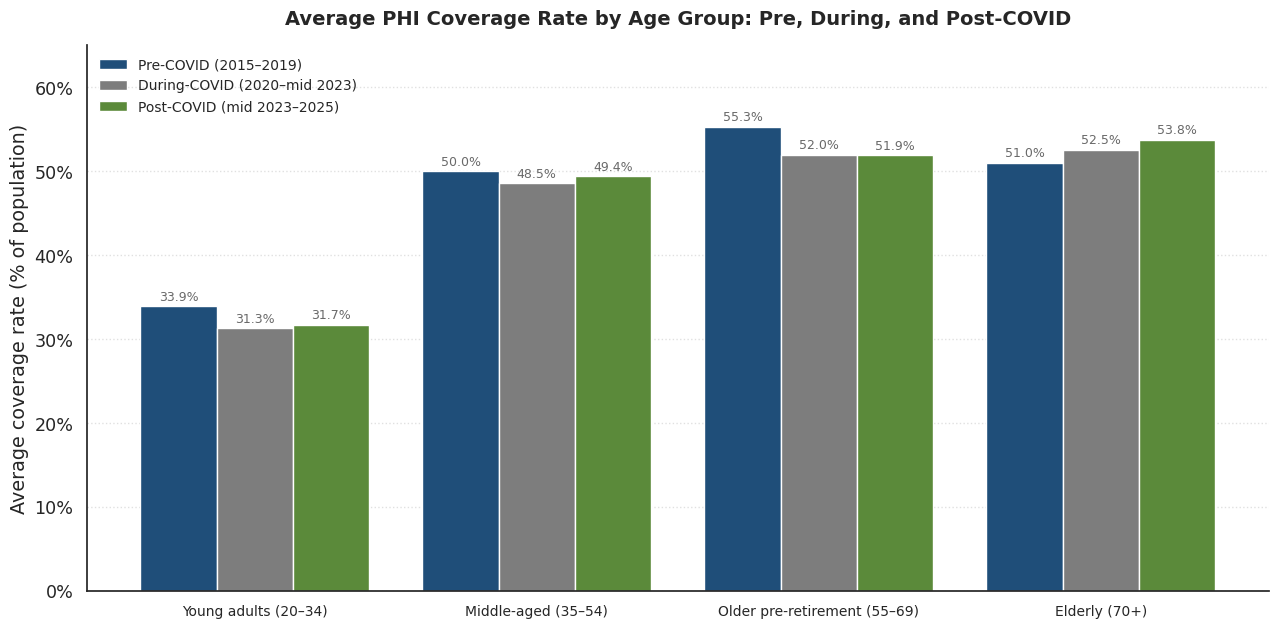

In [19]:
# === Chart 2.4: Average coverage rate by age band and period ===
fig, ax = plt.subplots(figsize=(13, 6.5))

periods = ['Pre-COVID (2015–2019)',
           'During-COVID (2020–mid 2023)',
           'Post-COVID (mid 2023–2025)']
period_colours = ['#1f4e79', '#7d7d7d', '#5b8a3a']  # navy, grey, green

x = np.arange(len(band_order))
width = 0.27

for i, period in enumerate(periods):
    values = [summary.loc[band, period] for band in band_order]
    bars = ax.bar(x + (i - 1) * width, values, width,
                  label=period, color=period_colours[i], edgecolor='white')
    # Value labels on top of each bar
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=9, color='dimgrey')

ax.set_title('Average PHI Coverage Rate by Age Group: Pre, During, and Post-COVID',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(band_order, fontsize=10)
ax.set_ylabel('Average coverage rate (% of population)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 65)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='upper left', frameon=False, fontsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation.** The summary table and accompanying chart consolidate the
age-group dynamics observed in Section 2.3 into three discrete periods, defined
using the WHO's official COVID-19 emergency window (March 2020 to May 2023).
Three patterns are worth emphasising.

**1. The pre-COVID decline was broad-based.** Coverage fell across every age band
except the elderly during the pandemic, with the older pre-retirement group (55–69)
losing the most (−3.31 pp), closely followed by young adults (−2.62 pp). This
contradicts a simple narrative in which only the young were exiting the market: the
during-COVID period affected most age groups simultaneously, likely reflecting
both economic pressure on households and the temporary inaccessibility of elective
hospital services that reduced the perceived value of private cover.

**2. The post-COVID recovery has been uneven and incomplete.** The middle-aged group
recovered most strongly (+0.84 pp), almost returning to pre-COVID levels. The young
adult rebound was much weaker (+0.41 pp), and the older pre-retirement group continued
to lose coverage even after the pandemic ended (−0.07 pp). As a result, the **net
change from pre-COVID to post-COVID is negative for every age group except the
elderly** — a structural deterioration that cannot be attributed to the pandemic alone.

**3. The ageing of the insured pool is the dominant structural trend.** The elderly
(70+) were the only age group whose coverage rose in *every* period, gaining 2.78
percentage points overall and overtaking the older pre-retirement group as the most
heavily insured age band by 2025. Because older insurees claim disproportionately more
benefits, this shifting age composition is the precise mechanism predicted by the
death-spiral hypothesis: a market increasingly funded by, and serving, older Australians,
with progressively less participation from the younger cohorts whose premiums are
needed to subsidise the system.

---
## Section 3 — Discussion and Sustainability Outlook

This section interprets the empirical patterns identified in Section 2, situates them
within the broader policy and economic context of Australian private health insurance,
and assesses what they imply for the future sustainability of the market. The
discussion draws on the analytical literature included in the assessment's reading
list to explain why the observed shifts occurred and what they signal going forward.

### 3.1 Why Did These Shifts Happen?

The trends documented in Section 2 — sustained growth in total membership, a declining
coverage rate from 2015 to 2021, and a marked ageing of the insured pool — reflect the
interaction of three forces: **affordability pressures**, **policy design**, and
**demographic change**.

**Affordability pressures.** Over the past two decades, PHI premiums have risen
substantially faster than wages and the consumer price index, eroding the real
purchasing power of insured households (Duckett & Moran, 2021). Because younger and
healthier adults have the weakest financial incentive to hold PHI — they use hospital
services least — they are also the most price-sensitive consumers and the first to
exit when premiums rise faster than perceived value. The disproportionate decline in
the 20–34 age group identified in Section 2.3 is consistent with this mechanism.

**Policy design.** The two great policy interventions of 1999–2000 — the 30% PHI
Rebate and the Lifetime Health Cover (LHC) loading — successfully lifted coverage
from approximately 30% to 46% within twelve months. However, both instruments have
weakened over time. The income thresholds for the Rebate were frozen in 2014,
gradually reducing its real value through inflation, and successive governments have
means-tested the Rebate so that higher-income households now receive a smaller
subsidy than before (Bilgrami et al., 2021). The LHC loading remains a strong
financial penalty for joining late, but its effect on the *under-31* population
relies on consumers anticipating long-term costs — an expectation that may be
weakening among younger Australians.

**Demographic change.** Australia's population is ageing, and older Australians
have a much stronger incentive to hold PHI because they expect to use it. The
elderly were the only group whose coverage rose in every period analysed (Section
2.4), gaining 2.50 percentage points net between pre- and post-COVID. As a result,
the insured pool is shifting older even without behavioural change, mechanically
increasing the average cost of claims and placing further upward pressure on
premiums — the textbook conditions for adverse selection (Barrett & Conlon, 2003).

**The COVID-19 shock.** The pandemic itself appears to have been a transitory rather
than structural event. The early-pandemic plateau in 2020–2021 reflected both
economic uncertainty and the suspension of elective surgery, which temporarily
reduced the perceived value of cover. The strong subsequent rebound from 2022 onwards
— particularly in total membership — suggests that demand for PHI was deferred rather
than destroyed. However, post-COVID recovery has not undone the *pre-COVID* decline
in age-group coverage, indicating that the underlying structural weaknesses pre-dated
the pandemic and remain unresolved.